In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from estimation_forecast_functions import DataCleaner_JPY
import holidays
from simple_strat_funcs import Clean_Implied_Vols_JPY_with_smile
from scipy.stats import norm
from hedging_strategy_class_NEW_KURT_SKEW_vega_VAR import Compare_Trading_Strategies
import seaborn as sns

/Users/alexvillamartin/Documents/MSc Diss/Code/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Global params

In [2]:
train_size = 0.7
test_size = 1 - train_size

TICKER = "USDJPY"

# always use same amount of money in USD to start and convert where necessary
IC_USD = 1_000_000 # initial capital in USD
current_rate = 147.52
IC_JPY = IC_USD * current_rate
NOTIONAL_USD = 1_000_000 # this is used in strategy as our notional to ensure trade positions are in domestic currency

MAX_DELTA_DIFF = 500 # this param doesnt change much as our delta positions are usually much larger
SIGNAL_LB = 0.01
SIGNAL_UB = 0.99
TRANSACTION_COST_BOOL = True
TRANSACTION_COSTS_SPOT = 0.0002 / 2 # for half a leg ie selling/buying once not to enter and exit the trade
TRANSACTION_COSTS_OPTION = 0.0005 / 2 # [change to vol spreads later] for half a leg again, both in decimals

HYPERPARAM_SORT = 'sharpe_ratio' # can be 'sharpe_ratio', 'cagr', 'max_drawdown', 'total_return'
GARCH_1_2_INDICATOR = False

k_bar_MSM = 8
b_MSM = 2.0
gamma_kbar_MSM = 0.5

M = 300 # figarch lags

CONVERT_USD_INDICATOR = True # convert all portfolio values and metrics to USD for fair comparison - use when USD is not domestic

long_threshs = np.array([1.02, 1.03, 1.04, 1.05, 1.06, 1.07,  1.08, 1.09, 1.10, 1.11, 1.12, 1.13, 1.14, 1.15, 1.16, 1.17, 1.18, 1.19, 1.20, 1.21, 1.22, 1.23, 1.24, 1.25, 1.26, 1.27])
short_threshs = np.array([0.98, 0.97, 0.96, 0.95, 0.94, 0.93, 0.92,  0.91, 0.90, 0.89, 0.88, 0.87, 0.86, 0.85, 0.84, 0.83, 0.82, 0.81, 0.80, 0.79, 0.78, 0.77, 0.76, 0.75, 0.74, 0.73])
sig_multipliers = np.array([1, 3, 5, 7, 9, 11, 13, 15, 17, 20])

# Global data

In [3]:
usdjpy_5m = pd.read_parquet("USD_JPY_5M.parquet").copy()[['c']]
usdjpy_5m.rename(columns={'c': 'spot'}, inplace=True)  
cleaner_usdjpy = DataCleaner_JPY(usdjpy_5m, start_hr=2, end_hr=18, unit_test=False) 
realised_variance_usdjpy = cleaner_usdjpy.clean_data()
daily_log_returns_usdjpy = pd.read_parquet("DF_D_USDJPY.parquet")['Log_r']
start_date = pd.to_datetime(realised_variance_usdjpy.index.min())
end_date = pd.to_datetime(realised_variance_usdjpy.index.max())
spot_curr = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_D_USDJPY.parquet")
overnight_domestic_rate = pd.read_csv("/Users/alexvillamartin/Documents/MSc Diss/Code/tona_daily.csv").set_index("Date") 
overnight_domestic_rate.index = (pd.to_datetime(overnight_domestic_rate.index, format='mixed').normalize())
overnight_foreign_rate = pd.read_csv("SOFR_daily.csv").set_index("date")

# Global functions

Change holidays where needed. 

In [4]:
def align_spots(df, aligned_df, start, end):

    df = df[(df.index >= start) & (df.index <= end)]

    years = range(start.year, end.year + 1)

    first = holidays.US(years=years)
    second = holidays.Japan(years=years)

    hols = pd.to_datetime(list(set(first) | set(second))).normalize()

    idx  = df.index
    mask = ~idx.isin(hols)
    new_df = df.loc[mask]

    df_aligned_dates = aligned_df.index
    common_dates = new_df.index.intersection(df_aligned_dates)
    new_df = new_df.loc[common_dates]

    return new_df

def sort_rates(r_b, r_t, overn_r, aligned_df, overn_for_r):

    r_b.index = pd.to_datetime(r_b.index)
    valid_mask = ~( 
                   r_t.index.isna())
    r_t_clean = r_t[valid_mask]
    r_t_clean.index = pd.to_datetime(r_t_clean.index, format='%Y-%m-%d')
    
    valid_mask2 = ~(
                   overn_r.index.isna())
    overn_r_clean = overn_r[valid_mask2]
    overn_r_clean.index = pd.to_datetime(overn_r_clean.index, format='%Y-%m-%d')

    valid_mask3 = ~(
                   overn_for_r.index.isna())
    overn_for_r_clean = overn_for_r[valid_mask3]
    overn_for_r_clean.index = pd.to_datetime(overn_for_r_clean.index, format='mixed').normalize()    

    r_b = r_b.reindex(aligned_df.index)
    r_t_clean = r_t_clean.reindex(aligned_df.index)
    overn_r_clean = overn_r_clean.reindex(aligned_df.index)
    overn_for_r_clean = overn_for_r_clean.reindex(aligned_df.index)

    r_b = r_b.ffill()
    r_t_clean = r_t_clean.ffill()
    overn_r_clean = overn_r_clean.ffill()
    overn_for_r_clean = overn_for_r_clean.ffill()

    # convert into decimals and continously compunded versions for BSE
    r_b = pd.to_numeric(r_b['rate_pct'], errors='coerce')
    r_t_clean = pd.to_numeric(r_t_clean['rate_pct'], errors='coerce')
    overn_r_clean = pd.to_numeric(overn_r_clean['tona_pct'], errors='coerce')
    r_b = r_b / 100
    r_t_clean = r_t_clean / 100
    overn_r_clean = overn_r_clean / 100 # not continously compounded
    overn_r_clean *= 1/365 # daily

    overn_for_r_clean = pd.to_numeric(overn_for_r_clean['value'], errors='coerce')
    overn_for_r_clean = overn_for_r_clean / 100 # not continously compounded
    overn_for_r_clean *= 1/365 # daily

    r_b = np.log(1 + r_b)
    r_t_clean = np.log(1 + r_t_clean)

    return r_b, r_t_clean, overn_r_clean, overn_for_r_clean

# H=30, T=1Mo

In [10]:
OPTION_MATURITY_1 = 1 / 12
H_1 = 30 

implied_vol_data_1 = pd.read_excel('/Users/alexvillamartin/Documents/MSc Diss/Code/USDJPY_1MO_ATM_D.xlsx')
vol_smile_data_1 = pd.read_csv("usdjpy_vol_smile_1mo_extra.csv").set_index("CalculationDate")
Data_clean_1 = Clean_Implied_Vols_JPY_with_smile(data=implied_vol_data_1, 
                                start_date=start_date, 
                                end_date=end_date, 
                                align_df1=realised_variance_usdjpy, 
                                align_df2=daily_log_returns_usdjpy, 
                                smile_df=vol_smile_data_1)
implied_vol_data_1, realised_variance_1, daily_log_returns_1, vol_smile_data_1 = Data_clean_1.get_clean_data()

N_1 = len(daily_log_returns_1)
test_align_1 = daily_log_returns_1.iloc[N_1//2:-H_1]
spot_curr_test_1 = align_spots(spot_curr, test_align_1, start_date, end_date)

r_b_1 = pd.read_csv("SOFR_1mo_compounded.csv").set_index("date")
r_t_1 = pd.read_csv("/Users/alexvillamartin/Documents/MSc Diss/Code/tona_1mo_compounded.csv").set_index("Date")[['rate_pct']]

r_b_test_1, r_t_test_1, overn_dom_r_test_1, overn_for_r_test_1= sort_rates(r_b_1, r_t_1, overnight_domestic_rate, test_align_1, overnight_foreign_rate) 
r_b_test_1.ffill(inplace=True)

Estimated parameters: m0=1.324502e+00, sigma_bar=5.592794e-01
Final log-likelihood: -8.254789e+02
Estimated parameters: m0=1.314606e+00, sigma_bar=5.547390e-01
Final log-likelihood: -1.380087e+03


[I 2025-09-03 21:08:03,802] A new study created in memory with name: no-name-55a67d03-6d8e-4759-a58a-664abc4af36f
[I 2025-09-03 21:08:04,510] Trial 0 finished with value: 0.34523967546666323 and parameters: {'long_threshold': 1.1, 'short_threshold': 0.83, 'signal_multiplier': 20}. Best is trial 0 with value: 0.34523967546666323.
[I 2025-09-03 21:08:05,288] Trial 1 finished with value: -0.019683491496742044 and parameters: {'long_threshold': 1.15, 'short_threshold': 0.96, 'signal_multiplier': 17}. Best is trial 0 with value: 0.34523967546666323.
[I 2025-09-03 21:08:05,980] Trial 2 finished with value: -0.5631247935830379 and parameters: {'long_threshold': 1.18, 'short_threshold': 0.91, 'signal_multiplier': 7}. Best is trial 0 with value: 0.34523967546666323.
[I 2025-09-03 21:08:06,560] Trial 3 finished with value: 0.12961866715272516 and parameters: {'long_threshold': 1.14, 'short_threshold': 0.76, 'signal_multiplier': 20}. Best is trial 0 with value: 0.34523967546666323.
[I 2025-09-03 

Estimated parameters: omega=0.0037585331153215874, alpha=0.0672, beta=0.9232
Estimated parameters: omega=0.0024381607944387444, alpha=0.0601, beta=0.9340


[I 2025-09-03 21:16:20,154] A new study created in memory with name: no-name-de0b6fcd-8ec1-4694-bef9-0dd7eda0f11b
[I 2025-09-03 21:16:20,808] Trial 0 finished with value: 0.9157861853250032 and parameters: {'long_threshold': 1.1, 'short_threshold': 0.83, 'signal_multiplier': 20}. Best is trial 0 with value: 0.9157861853250032.
[I 2025-09-03 21:16:21,493] Trial 1 finished with value: 0.5869017576366086 and parameters: {'long_threshold': 1.15, 'short_threshold': 0.96, 'signal_multiplier': 17}. Best is trial 0 with value: 0.9157861853250032.
[I 2025-09-03 21:16:22,161] Trial 2 finished with value: -0.008046263547377286 and parameters: {'long_threshold': 1.18, 'short_threshold': 0.91, 'signal_multiplier': 7}. Best is trial 0 with value: 0.9157861853250032.
[I 2025-09-03 21:16:22,793] Trial 3 finished with value: 0.8194883884041712 and parameters: {'long_threshold': 1.14, 'short_threshold': 0.76, 'signal_multiplier': 20}. Best is trial 0 with value: 0.9157861853250032.
[I 2025-09-03 21:16:2

Estimated parameters: omega=0.07868108445557308, d=0.2129, beta=0.0485
Final log-likelihood = 398.4028
Estimated parameters: omega=0.05459404140392503, d=0.2697, beta=0.1474
Final log-likelihood = 690.6127


[I 2025-09-03 21:24:53,900] A new study created in memory with name: no-name-c199a12e-4e99-4d80-a0e3-a865ee9f753e
[I 2025-09-03 21:24:54,598] Trial 0 finished with value: 0.47050171690994536 and parameters: {'long_threshold': 1.1, 'short_threshold': 0.83, 'signal_multiplier': 20}. Best is trial 0 with value: 0.47050171690994536.
[I 2025-09-03 21:24:55,364] Trial 1 finished with value: 0.019587031172108044 and parameters: {'long_threshold': 1.15, 'short_threshold': 0.96, 'signal_multiplier': 17}. Best is trial 0 with value: 0.47050171690994536.
[I 2025-09-03 21:24:56,060] Trial 2 finished with value: -0.5778764969375642 and parameters: {'long_threshold': 1.18, 'short_threshold': 0.91, 'signal_multiplier': 7}. Best is trial 0 with value: 0.47050171690994536.
[I 2025-09-03 21:24:56,671] Trial 3 finished with value: 0.3605178074667331 and parameters: {'long_threshold': 1.14, 'short_threshold': 0.76, 'signal_multiplier': 20}. Best is trial 0 with value: 0.47050171690994536.
[I 2025-09-03 21

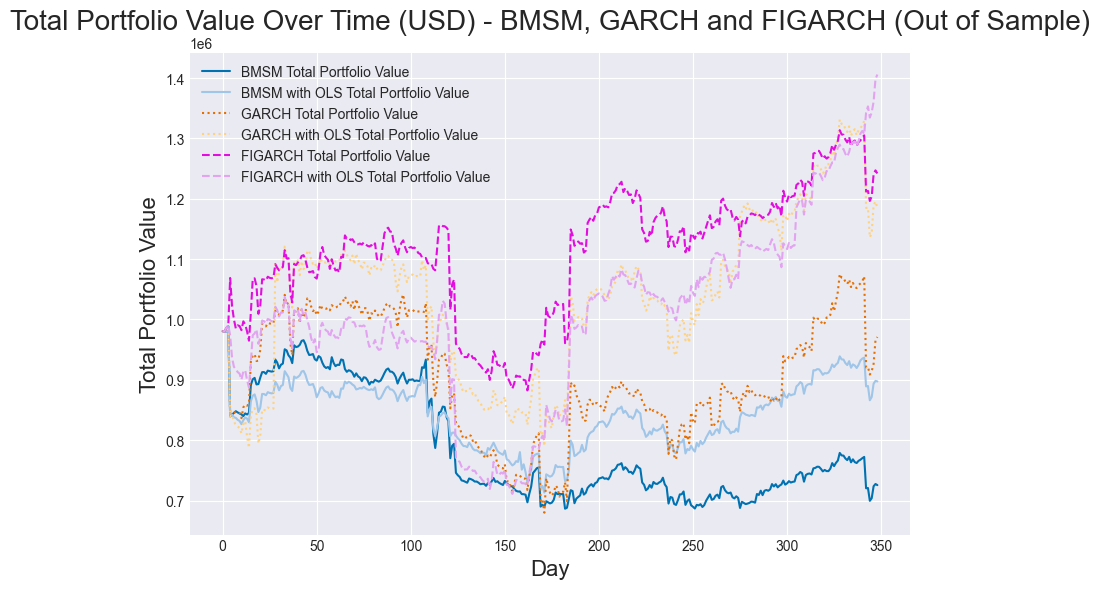

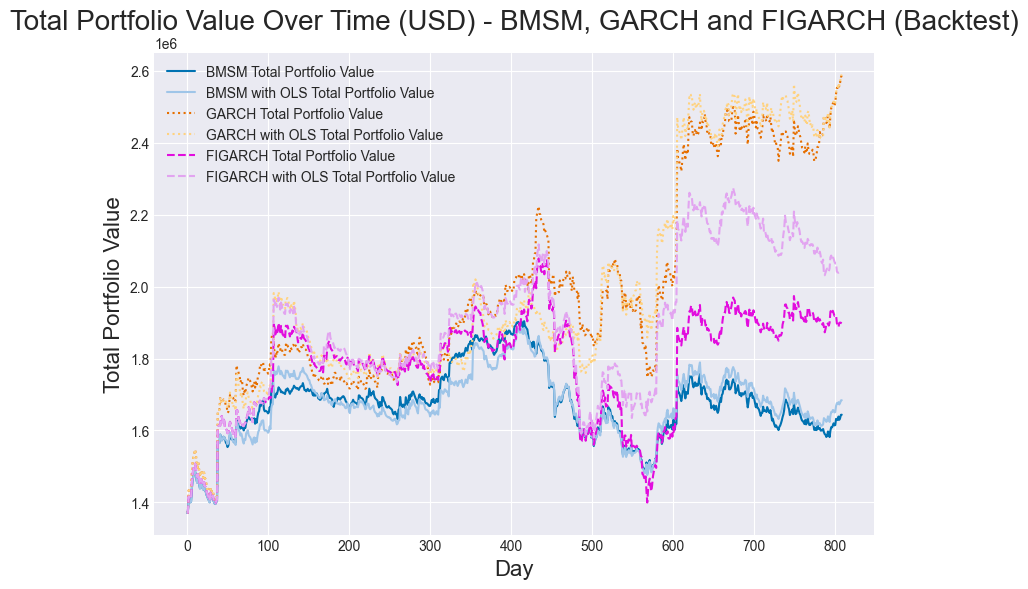

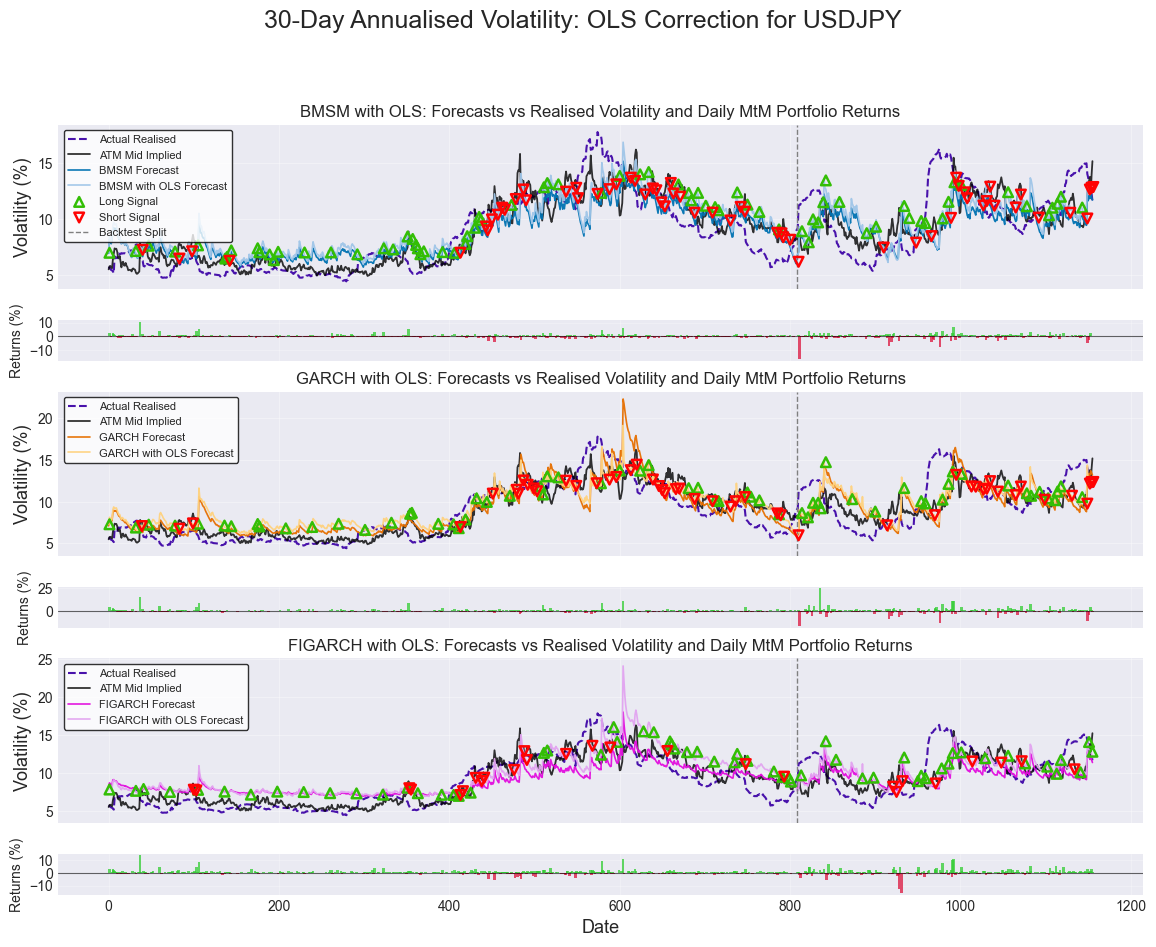

In [11]:
strategy_1 = Compare_Trading_Strategies(
    return_series=daily_log_returns_1, 
    realised_variance_series=realised_variance_1,
    atm_implied_vol_data=implied_vol_data_1,
    vol_smile_data=vol_smile_data_1,
    train_size=train_size,
    ticker=TICKER,
    initial_capital_domestic=IC_JPY,
    notional_base=NOTIONAL_USD,
    maximum_delta_difference=MAX_DELTA_DIFF,
    signal_lb=SIGNAL_LB,
    signal_ub=SIGNAL_UB,
    transaction_cost_indicator=TRANSACTION_COST_BOOL,
    transaction_costs_spot=TRANSACTION_COSTS_SPOT,
    transaction_costs_option=TRANSACTION_COSTS_OPTION,
    option_maturity=OPTION_MATURITY_1,
    forecast_horizon=H_1,
    spot_series=spot_curr_test_1,
    overnight_domestic_rate=overn_dom_r_test_1,
    overnight_foreign_rate=overn_for_r_test_1,
    domestic_rate=r_t_test_1,
    foreign_rate=r_b_test_1, 
    plots = False, 
    verbose=False, 
    sort_hyperparams_by=HYPERPARAM_SORT, 
    garch_1_2_indicator=GARCH_1_2_INDICATOR, 
    kbar=k_bar_MSM,
    b=b_MSM,
    gamma_kbar=gamma_kbar_MSM,
    convert_USD=CONVERT_USD_INDICATOR, 
    M = M, 
    long_thresholds=long_threshs,
    short_thresholds=short_threshs,
    sig_multipliers=sig_multipliers)

df_1 = strategy_1.compare_strategies(verbose = False)

In [9]:
error_metrics_df_1 = strategy_1.get_statistical_error_metrics_for_all()

In [10]:
error_metrics_df_1

,Norm MSE,DM Test Stat MSE,DM p-value (one-sided) MSE,Norm MAE,DM Test Stat MAE,DM p-value (one-sided) MAE
BMSM,0.480103,NaN,NaN,0.621672,NaN,NaN
BMSM OLS,0.486895,0.927990,0.823197,0.621217,-0.079169,0.468456
GARCH,0.508184,NaN,NaN,0.614745,NaN,NaN
GARCH OLS,0.480999,-0.630475,0.264254,0.597001,-0.612613,0.270126
FIGARCH,0.559193,NaN,NaN,0.708127,NaN,NaN
FIGARCH OLS,0.547482,-0.267043,0.394742,0.681910,-0.772825,0.219892


In [11]:
error_metrics_df_1.to_csv("USDJPY_Errors_H_30_T_1MO_OLS.csv")

In [12]:
df_1

,long_threshold,short_threshold,signal_multiplier,sharpe_ratio (USD),max_drawdown (USD),calmar_ratio (USD),cagr (USD),Precision (all),Precision (active),Win/loss ratio (all),Win/loss ratio (active),Avg win (all),Avg win (active),Avg loss (all),Avg loss (active),Non-active share,Total trades
BMSM Backtest,1.26,0.80,20.00,0.43,-22.21,0.25,5.80%,0.46,0.49,1.26,1.58,0.58%,0.76%,-0.46%,-0.48%,0.50,86.00
BMSM Out of Sample,1.26,0.80,20.00,-0.82,-30.57,-0.72,-19.55%,0.51,0.56,0.79,0.58,0.77%,1.04%,-0.97%,-1.78%,0.58,37.00
BMSM with OLS Backtest,1.18,0.94,20.00,0.45,-21.68,0.30,6.60%,0.44,0.45,1.37,1.53,0.63%,0.70%,-0.46%,-0.46%,0.25,89.00
BMSM with OLS Out of Sample,1.18,0.94,20.00,-0.27,-27.88,-0.24,-6.21%,0.50,0.51,0.93,0.89,0.83%,0.96%,-0.89%,-1.09%,0.33,45.00
GARCH Backtest,1.11,0.74,20.00,1.02,-21.40,0.92,21.86%,0.45,0.46,1.54,1.83,0.81%,1.05%,-0.52%,-0.58%,0.39,62.00
GARCH Out of Sample,1.11,0.74,20.00,-0.02,-34.71,-0.02,-0.71%,0.48,0.48,1.07,1.07,1.36%,2.06%,-1.27%,-1.93%,0.46,30.00
GARCH with OLS Backtest,1.13,0.89,20.00,1.02,-12.88,1.54,21.89%,0.45,0.45,1.54,1.76,0.81%,0.94%,-0.53%,-0.53%,0.25,70.00
GARCH with OLS Out of Sample,1.13,0.89,20.00,0.31,-29.49,0.46,14.65%,0.50,0.50,1.09,1.07,1.45%,1.89%,-1.33%,-1.77%,0.33,42.00
FIGARCH Backtest,1.05,0.77,20.00,0.53,-32.65,0.31,10.65%,0.44,0.44,1.42,1.56,0.79%,0.92%,-0.56%,-0.59%,0.29,61.00
FIGARCH Out of Sample,1.05,0.77,20.00,0.55,-23.69,0.72,18.60%,0.50,0.49,1.15,1.25,1.09%,1.51%,-0.95%,-1.21%,0.39,39.00


In [13]:
df_1.data.to_csv("USDJPY_Strategy_H_30_T_1MO.csv", index=True)

In [14]:
strategy_1.model_bmsm_oos.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.027
Model:                            OLS   Adj. R-squared:                  0.025
Method:                 Least Squares   F-statistic:                     2.242
Date:                Tue, 26 Aug 2025   Prob (F-statistic):             0.0623
Time:                        11:12:08   Log-Likelihood:                -113.88
No. Observations:                1963   AIC:                             237.8
Df Residuals:                    1958   BIC:                             265.7
Df Model:                           4                                         
Covariance Type:                  HAC                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0553      0.016     -3.555      0.000      -0.086      -0.025
x1             0.0330      0.027      1.210      0.226      -0.020       0.087
x2            -0.0092      0.029     -0.321      0.748      -0.065       0.047
x3             0.0139      0.018      0.766      0.444      -0.022       0.050
x4            -0.0169      0.021     -0.817      0.414      -0.058       0.024
==============================================================================
Omnibus:                      467.811   Durbin-Watson:                   0.070
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1270.811
Skew:                           1.244   Prob(JB):                    1.11e-276
Kurtosis:                       6.057   Cond. No.                         4.90
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 7 lags and without small sample correction
"""

In [15]:
strategy_1.model_garch_oos.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                    0.5933
Date:                Tue, 26 Aug 2025   Prob (F-statistic):              0.619
Time:                        11:12:12   Log-Likelihood:                -190.73
No. Observations:                1963   AIC:                             389.5
Df Residuals:                    1959   BIC:                             411.8
Df Model:                           3                                         
Covariance Type:                  HAC                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0471      0.016     -2.889      0.004      -0.079      -0.015
x1             0.0157      0.021      0.760      0.447      -0.025       0.056
x2             0.0216      0.020      1.067      0.286      -0.018       0.061
x3            -0.0044      0.020     -0.221      0.825      -0.043       0.035
==============================================================================
Omnibus:                      367.517   Durbin-Watson:                   0.055
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              893.864
Skew:                           1.025   Prob(JB):                    7.94e-195
Kurtosis:                       5.594   Cond. No.                         2.23
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 7 lags and without small sample correction
"""

In [16]:
strategy_1.model_figarch_oos.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.071
Model:                            OLS   Adj. R-squared:                  0.070
Method:                 Least Squares   F-statistic:                     6.071
Date:                Tue, 26 Aug 2025   Prob (F-statistic):           0.000413
Time:                        11:12:14   Log-Likelihood:                -152.26
No. Observations:                1963   AIC:                             312.5
Df Residuals:                    1959   BIC:                             334.9
Df Model:                           3                                         
Covariance Type:                  HAC                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0665      0.016     -4.146      0.000      -0.098      -0.035
x1             0.0126      0.013      0.990      0.322      -0.012       0.037
x2             0.0349      0.018      1.917      0.055      -0.001       0.070
x3            -0.0559      0.018     -3.146      0.002      -0.091      -0.021
==============================================================================
Omnibus:                      508.299   Durbin-Watson:                   0.046
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1305.147
Skew:                           1.379   Prob(JB):                    3.90e-284
Kurtosis:                       5.890   Cond. No.                         1.91
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 7 lags and without small sample correction
"""

# H=91, T=3MO

In [5]:
OPTION_MATURITY_2 = 3 / 12
H_2 = 91 

vol_smile_data_2 = pd.read_csv("usdjpy_vol_smile_3mo_extra.csv").set_index("CalculationDate")
implied_vol_data_2 = pd.DataFrame({
    'Exchange Date': vol_smile_data_2.index, 
    "Bid": vol_smile_data_2['ATM'], 
    "Ask": vol_smile_data_2['ATM'],
    "BidNet": vol_smile_data_2['ATM']})
Data_clean_2 = Clean_Implied_Vols_JPY_with_smile(data=implied_vol_data_2, 
                                start_date=start_date, 
                                end_date=end_date, 
                                align_df1=realised_variance_usdjpy, 
                                align_df2=daily_log_returns_usdjpy, 
                                smile_df=vol_smile_data_2)
implied_vol_data_2, realised_variance_2, daily_log_returns_2, vol_smile_data_2 = Data_clean_2.get_clean_data()

N_2 = len(daily_log_returns_2)
test_align_2 = daily_log_returns_2.iloc[N_2//2:-H_2]
spot_curr_test_2 = align_spots(spot_curr, test_align_2, start_date, end_date)

r_b_2 = pd.read_csv("SOFR_3mo_compounded.csv").set_index("date")
r_t_2 = pd.read_csv("/Users/alexvillamartin/Documents/MSc Diss/Code/tona_3mo_compounded.csv").set_index("Date")[['rate_pct']]

r_b_test_2, r_t_test_2, overn_dom_r_test_2, overn_for_r_test_2= sort_rates(r_b_2, r_t_2, overnight_domestic_rate, test_align_2, overnight_foreign_rate) 
r_b_test_2.ffill(inplace=True)

Estimated parameters: m0=1.324502e+00, sigma_bar=5.592794e-01
Final log-likelihood: -8.254789e+02
Estimated parameters: m0=1.308990e+00, sigma_bar=5.670236e-01
Final log-likelihood: -1.366077e+03


[I 2025-09-03 18:33:37,581] A new study created in memory with name: no-name-10f1823a-13c3-4d67-981f-32c0ff0b116c
[I 2025-09-03 18:33:38,305] Trial 0 finished with value: 0.2163224234262234 and parameters: {'long_threshold': 1.1, 'short_threshold': 0.83, 'signal_multiplier': 20}. Best is trial 0 with value: 0.2163224234262234.
[I 2025-09-03 18:33:39,032] Trial 1 finished with value: 0.19507997396616844 and parameters: {'long_threshold': 1.15, 'short_threshold': 0.96, 'signal_multiplier': 17}. Best is trial 0 with value: 0.2163224234262234.
[I 2025-09-03 18:33:39,731] Trial 2 finished with value: -0.26459870387904355 and parameters: {'long_threshold': 1.18, 'short_threshold': 0.91, 'signal_multiplier': 7}. Best is trial 0 with value: 0.2163224234262234.
[I 2025-09-03 18:33:40,410] Trial 3 finished with value: -0.025791183246262162 and parameters: {'long_threshold': 1.14, 'short_threshold': 0.76, 'signal_multiplier': 20}. Best is trial 0 with value: 0.2163224234262234.
[I 2025-09-03 18:3

Estimated parameters: omega=0.0037585331153215874, alpha=0.0672, beta=0.9232
Estimated parameters: omega=0.00229459625455363, alpha=0.0559, beta=0.9387


[I 2025-09-03 18:43:09,474] A new study created in memory with name: no-name-9ccf4480-9e51-4541-8f5a-f37e5de903ef
[I 2025-09-03 18:43:10,218] Trial 0 finished with value: 0.3129762478361932 and parameters: {'long_threshold': 1.1, 'short_threshold': 0.83, 'signal_multiplier': 20}. Best is trial 0 with value: 0.3129762478361932.
[I 2025-09-03 18:43:10,990] Trial 1 finished with value: 0.3782773565466189 and parameters: {'long_threshold': 1.15, 'short_threshold': 0.96, 'signal_multiplier': 17}. Best is trial 1 with value: 0.3782773565466189.
[I 2025-09-03 18:43:11,675] Trial 2 finished with value: 0.048316218908021874 and parameters: {'long_threshold': 1.18, 'short_threshold': 0.91, 'signal_multiplier': 7}. Best is trial 1 with value: 0.3782773565466189.
[I 2025-09-03 18:43:12,416] Trial 3 finished with value: 0.5696368446641223 and parameters: {'long_threshold': 1.14, 'short_threshold': 0.76, 'signal_multiplier': 20}. Best is trial 3 with value: 0.5696368446641223.
[I 2025-09-03 18:43:13

Estimated parameters: omega=0.07868108445557308, d=0.2129, beta=0.0485
Final log-likelihood = 398.4028
Estimated parameters: omega=0.05667073186735744, d=0.2664, beta=0.1479
Final log-likelihood = 646.8731


[I 2025-09-03 18:52:57,774] A new study created in memory with name: no-name-ad42f544-587b-4515-b129-cab03f33b871
[I 2025-09-03 18:52:58,559] Trial 0 finished with value: 0.6360097063502853 and parameters: {'long_threshold': 1.1, 'short_threshold': 0.83, 'signal_multiplier': 20}. Best is trial 0 with value: 0.6360097063502853.
[I 2025-09-03 18:52:59,311] Trial 1 finished with value: 1.024686333970839 and parameters: {'long_threshold': 1.15, 'short_threshold': 0.96, 'signal_multiplier': 17}. Best is trial 1 with value: 1.024686333970839.
[I 2025-09-03 18:53:00,017] Trial 2 finished with value: 0.23959556210932773 and parameters: {'long_threshold': 1.18, 'short_threshold': 0.91, 'signal_multiplier': 7}. Best is trial 1 with value: 1.024686333970839.
[I 2025-09-03 18:53:00,742] Trial 3 finished with value: 0.6934491550553957 and parameters: {'long_threshold': 1.14, 'short_threshold': 0.76, 'signal_multiplier': 20}. Best is trial 1 with value: 1.024686333970839.
[I 2025-09-03 18:53:01,564]

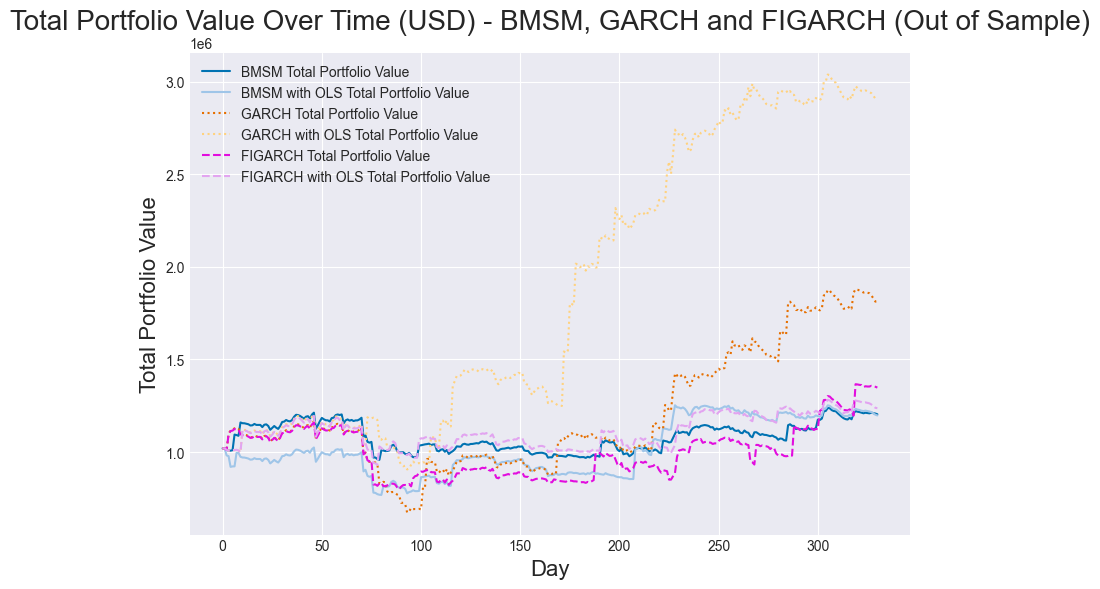

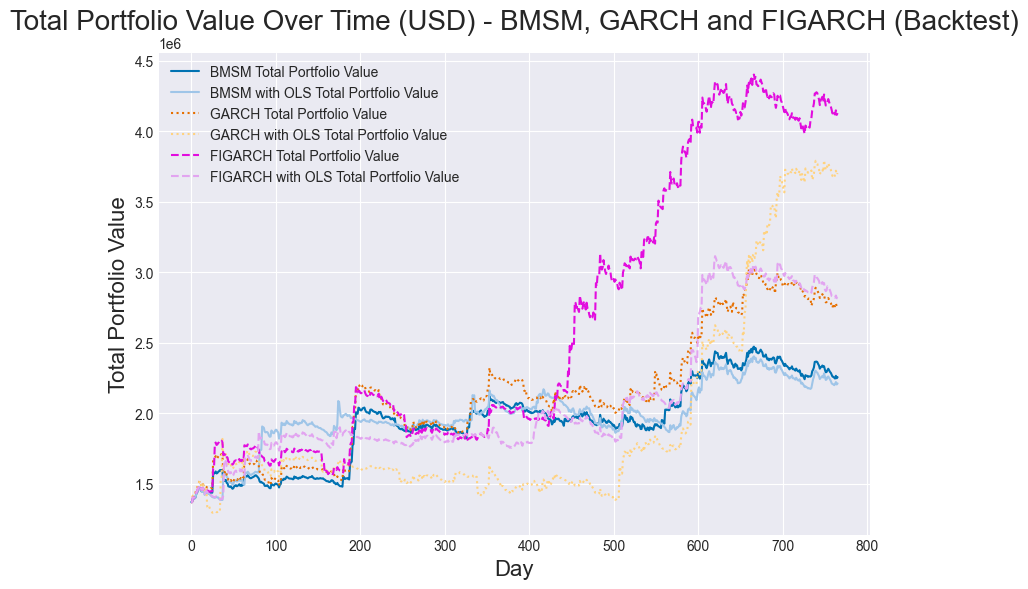

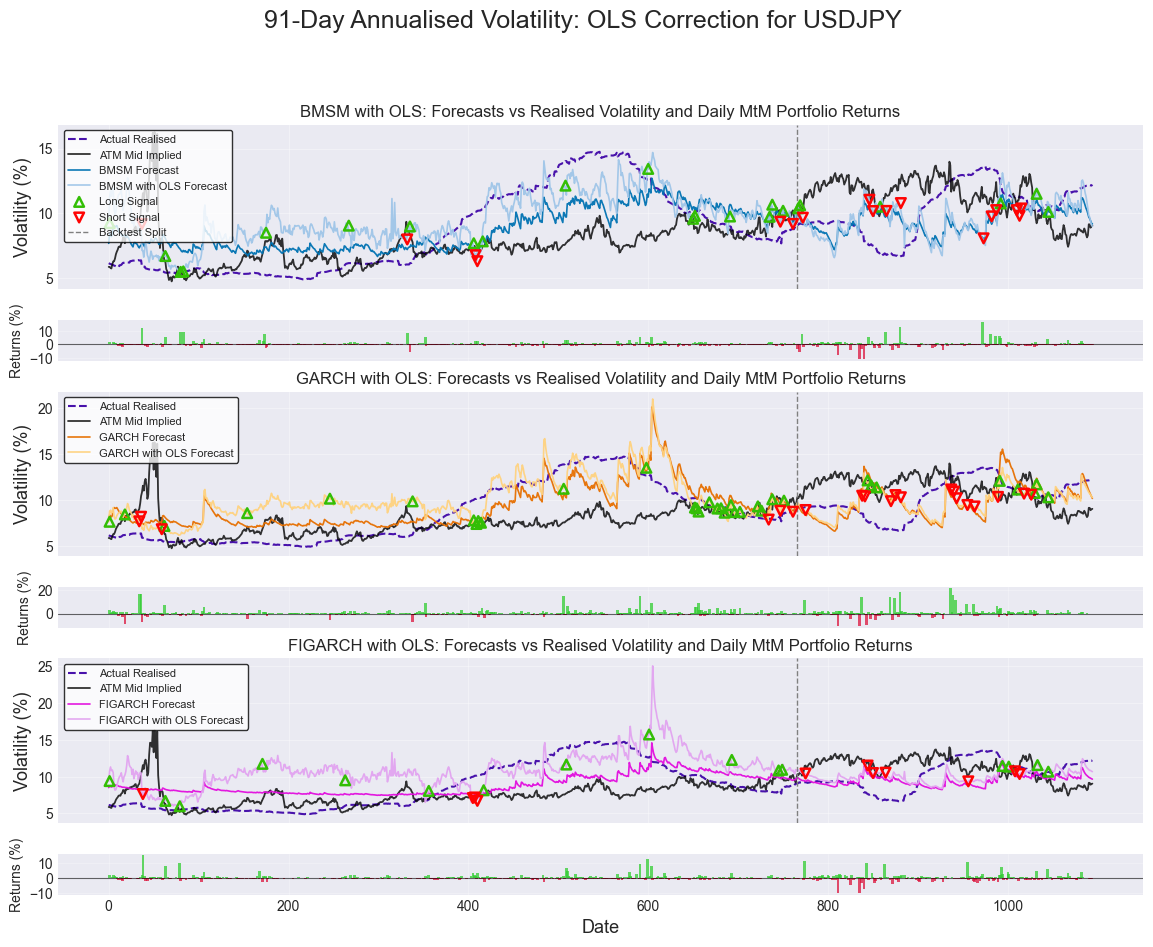

In [6]:
strategy_2 = Compare_Trading_Strategies(
    return_series=daily_log_returns_2, 
    realised_variance_series=realised_variance_2,
    atm_implied_vol_data=implied_vol_data_2,
    vol_smile_data=vol_smile_data_2,
    train_size=train_size,
    ticker=TICKER,
    initial_capital_domestic=IC_JPY,
    notional_base=NOTIONAL_USD,
    maximum_delta_difference=MAX_DELTA_DIFF,
    signal_lb=SIGNAL_LB,
    signal_ub=SIGNAL_UB,
    transaction_cost_indicator=TRANSACTION_COST_BOOL,
    transaction_costs_spot=TRANSACTION_COSTS_SPOT,
    transaction_costs_option=TRANSACTION_COSTS_OPTION,
    option_maturity=OPTION_MATURITY_2,
    forecast_horizon=H_2,
    spot_series=spot_curr_test_2,
    overnight_domestic_rate=overn_dom_r_test_2,
    overnight_foreign_rate=overn_for_r_test_2,
    domestic_rate=r_t_test_2,
    foreign_rate=r_b_test_2, 
    plots = False, 
    verbose=False, 
    sort_hyperparams_by=HYPERPARAM_SORT, 
    garch_1_2_indicator=GARCH_1_2_INDICATOR, 
    kbar=k_bar_MSM,
    b=b_MSM,
    gamma_kbar=gamma_kbar_MSM,
    convert_USD=CONVERT_USD_INDICATOR, 
    M = M, 
    long_thresholds=long_threshs,
    short_thresholds=short_threshs,
    sig_multipliers=sig_multipliers)

df_2 = strategy_2.compare_strategies(verbose = False)

/var/folders/ws/xbf0f9zj4qxc6drt1bjn4lg40000gn/T/ipykernel_38024/2967900992.py:4: RuntimeWarning: invalid value encountered in divide
  vega = np.hstack((strategy_2.vega_bmsm_bt_ols, strategy_2.vega_bmsm_oos_ols)) / np.hstack((strategy_2.trading_summary_bmsm_bt_ols['Notional Adjusted'], strategy_2.trading_summary_bmsm_oos_ols['Notional Adjusted']))
/var/folders/ws/xbf0f9zj4qxc6drt1bjn4lg40000gn/T/ipykernel_38024/2967900992.py:5: RuntimeWarning: invalid value encountered in divide
  gamma = np.hstack((strategy_2.gamma_bmsm_bt_ols, strategy_2.gamma_bmsm_oos_ols)) / np.hstack((strategy_2.trading_summary_bmsm_bt_ols['Notional Adjusted'], strategy_2.trading_summary_bmsm_oos_ols['Notional Adjusted']))


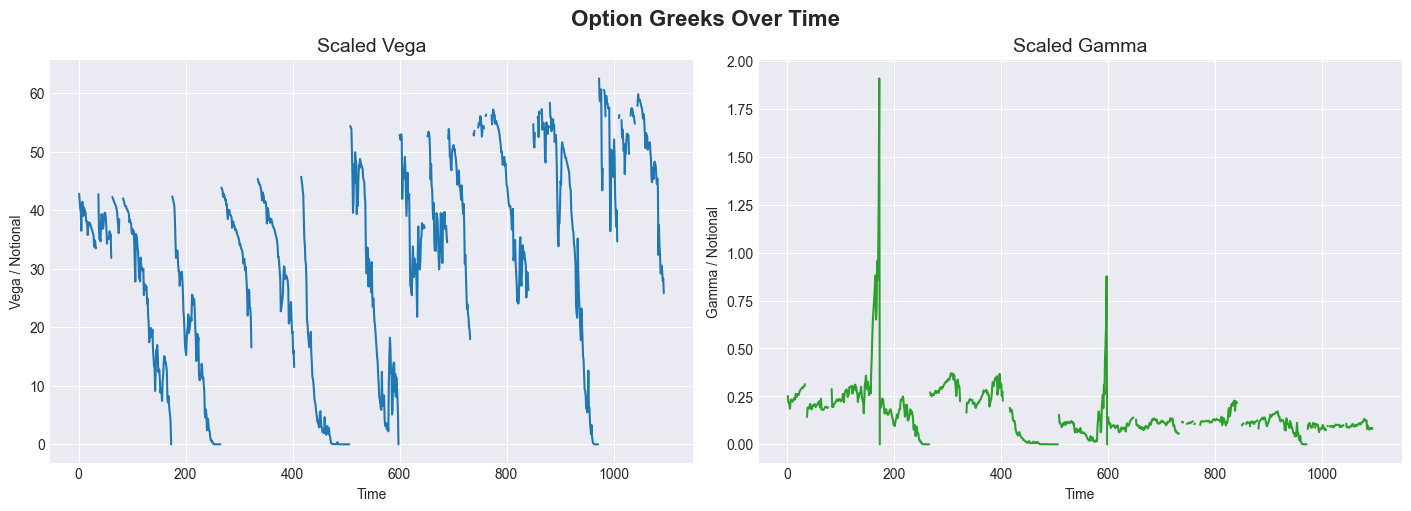

In [8]:
plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

vega = np.hstack((strategy_2.vega_bmsm_bt_ols, strategy_2.vega_bmsm_oos_ols)) / np.hstack((strategy_2.trading_summary_bmsm_bt_ols['Notional Adjusted'], strategy_2.trading_summary_bmsm_oos_ols['Notional Adjusted']))
gamma = np.hstack((strategy_2.gamma_bmsm_bt_ols, strategy_2.gamma_bmsm_oos_ols)) / np.hstack((strategy_2.trading_summary_bmsm_bt_ols['Notional Adjusted'], strategy_2.trading_summary_bmsm_oos_ols['Notional Adjusted']))

axes[0].plot(vega, color="tab:blue", lw=1.5)
axes[0].set_title("Scaled Vega", fontsize=14)
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Vega / Notional")

axes[1].plot(gamma, color="tab:green", lw=1.5)
axes[1].set_title("Scaled Gamma", fontsize=14)
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Gamma / Notional")

plt.suptitle("Option Greeks Over Time", fontsize=16, weight="bold")
plt.show()

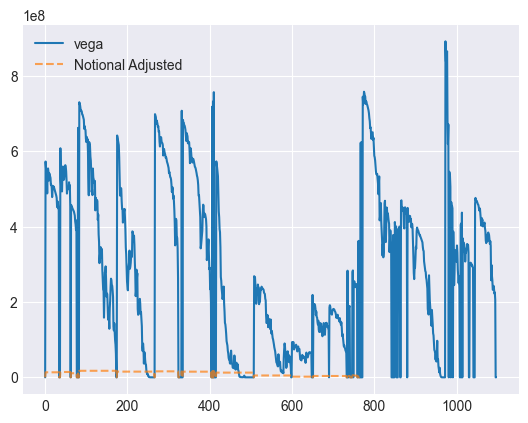

In [9]:
plt.plot(np.hstack((strategy_2.vega_bmsm_bt_ols,strategy_2.vega_bmsm_oos_ols)), label = 'vega')
plt.plot(strategy_2.trading_summary_bmsm_bt_ols['Notional Adjusted'], label = 'Notional Adjusted', linestyle = '--', alpha = 0.7)
plt.legend()

In [7]:
df_2

,long_threshold,short_threshold,signal_multiplier,sharpe_ratio (USD),max_drawdown (USD),calmar_ratio (USD),cagr (USD),Precision (all),Precision (active),Win/loss ratio (all),Win/loss ratio (active),Avg win (all),Avg win (active),Avg loss (all),Avg loss (active),Non-active share,Total trades
BMSM Backtest,1.26,0.83,20.00,1.01,-11.64,1.41,17.80%,0.44,0.45,1.61,1.88,0.73%,0.93%,-0.46%,-0.50%,0.32,31.00
BMSM Out of Sample,1.26,0.83,20.00,0.50,-21.00,0.60,13.47%,0.48,0.50,1.20,1.22,0.94%,1.03%,-0.78%,-0.85%,0.19,15.00
BMSM with OLS Backtest,1.07,0.86,20.00,0.87,-14.21,1.11,17.03%,0.41,0.40,1.78,1.85,0.79%,0.83%,-0.44%,-0.45%,0.07,23.00
BMSM with OLS Out of Sample,1.07,0.86,20.00,0.37,-24.98,0.49,13.02%,0.47,0.47,1.26,1.29,1.11%,1.20%,-0.88%,-0.94%,0.10,17.00
GARCH Backtest,1.25,0.87,20.00,1.08,-16.71,1.38,25.96%,0.43,0.44,1.73,1.93,0.93%,1.17%,-0.53%,-0.60%,0.29,30.00
GARCH Out of Sample,1.25,0.87,20.00,1.00,-42.32,1.04,54.97%,0.46,0.48,1.49,1.47,1.66%,1.79%,-1.11%,-1.22%,0.14,18.00
GARCH with OLS Backtest,1.05,0.76,20.00,1.19,-23.72,1.38,38.65%,0.44,0.44,1.78,1.88,1.10%,1.20%,-0.62%,-0.64%,0.12,32.00
GARCH with OLS Out of Sample,1.05,0.76,20.00,1.74,-24.63,3.24,121.72%,0.47,0.49,1.87,1.82,1.73%,1.98%,-0.93%,-1.09%,0.21,22.00
FIGARCH Backtest,1.27,0.97,20.00,1.55,-17.16,2.12,43.69%,0.45,0.47,1.78,1.94,1.02%,1.23%,-0.57%,-0.64%,0.26,43.00
FIGARCH Out of Sample,1.27,0.97,20.00,0.54,-31.13,0.68,23.67%,0.50,0.51,1.16,1.12,1.30%,1.38%,-1.12%,-1.23%,0.14,13.00


In [23]:
df_2.data.to_csv("USDJPY_Strategy_H_91_T_3MO.csv", index=True)

In [24]:
strategy_2.model_bmsm_oos.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.158
Model:                            OLS   Adj. R-squared:                  0.156
Method:                 Least Squares   F-statistic:                     20.15
Date:                Tue, 26 Aug 2025   Prob (F-statistic):           2.95e-16
Time:                        13:52:16   Log-Likelihood:                 61.773
No. Observations:                1859   AIC:                            -113.5
Df Residuals:                    1854   BIC:                            -85.91
Df Model:                           4                                         
Covariance Type:                  HAC                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0492      0.015     -3.301      0.001      -0.078      -0.020
x1             0.1286      0.028      4.515      0.000       0.073       0.184
x2             0.0083      0.028      0.294      0.769      -0.047       0.064
x3             0.0207      0.020      1.044      0.297      -0.018       0.060
x4             0.0926      0.025      3.653      0.000       0.043       0.142
==============================================================================
Omnibus:                       96.640   Durbin-Watson:                   0.053
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              111.158
Skew:                           0.598   Prob(JB):                     7.28e-25
Kurtosis:                       3.084   Cond. No.                         5.75
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 7 lags and without small sample correction
"""

In [26]:
strategy_2.model_garch_oos.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.091
Model:                            OLS   Adj. R-squared:                  0.090
Method:                 Least Squares   F-statistic:                     11.79
Date:                Tue, 26 Aug 2025   Prob (F-statistic):           1.20e-07
Time:                        14:28:53   Log-Likelihood:                -12.828
No. Observations:                1859   AIC:                             33.66
Df Residuals:                    1855   BIC:                             55.77
Df Model:                           3                                         
Covariance Type:                  HAC                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0639      0.016     -4.089      0.000      -0.094      -0.033
x1            -0.0379      0.020     -1.879      0.060      -0.078       0.002
x2             0.0430      0.020      2.157      0.031       0.004       0.082
x3             0.0674      0.021      3.258      0.001       0.027       0.108
==============================================================================
Omnibus:                       69.181   Durbin-Watson:                   0.034
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               76.160
Skew:                           0.480   Prob(JB):                     2.90e-17
Kurtosis:                       3.248   Cond. No.                         2.28
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 7 lags and without small sample correction
"""

In [27]:
strategy_2.model_figarch_oos.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.100
Model:                            OLS   Adj. R-squared:                  0.099
Method:                 Least Squares   F-statistic:                     8.890
Date:                Tue, 26 Aug 2025   Prob (F-statistic):           7.54e-06
Time:                        14:28:56   Log-Likelihood:                -101.48
No. Observations:                1859   AIC:                             211.0
Df Residuals:                    1855   BIC:                             233.1
Df Model:                           3                                         
Covariance Type:                  HAC                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0479      0.017     -2.890      0.004      -0.080      -0.015
x1             0.0209      0.013      1.631      0.103      -0.004       0.046
x2             0.0788      0.017      4.745      0.000       0.046       0.111
x3            -0.0125      0.021     -0.586      0.558      -0.054       0.029
==============================================================================
Omnibus:                      137.885   Durbin-Watson:                   0.014
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              149.232
Skew:                           0.658   Prob(JB):                     3.93e-33
Kurtosis:                       2.561   Cond. No.                         2.00
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 7 lags and without small sample correction
"""

# H=182, T=6MO

In [13]:
OPTION_MATURITY_3 = 6 / 12
H_3 = 182

vol_smile_data_3 = pd.read_csv("usdjpy_vol_smile_6mo_extra.csv").set_index("CalculationDate")
implied_vol_data_3 = pd.DataFrame({
    'Exchange Date': vol_smile_data_3.index, 
    "Bid": vol_smile_data_3['ATM'], 
    "Ask": vol_smile_data_3['ATM'],
    "BidNet": vol_smile_data_3['ATM']})
Data_clean_3 = Clean_Implied_Vols_JPY_with_smile(data=implied_vol_data_3, 
                                start_date=start_date, 
                                end_date=end_date, 
                                align_df1=realised_variance_usdjpy, 
                                align_df2=daily_log_returns_usdjpy, 
                                smile_df=vol_smile_data_3)
implied_vol_data_3, realised_variance_3, daily_log_returns_3, vol_smile_data_3 = Data_clean_3.get_clean_data()

N_3 = len(daily_log_returns_3)
test_align_3 = daily_log_returns_3.iloc[N_3//2:-H_3]
spot_curr_test_3 = align_spots(spot_curr, test_align_3, start_date, end_date)

r_b_3 = pd.read_csv("SOFR_6mo_compounded.csv").set_index("date")
r_t_3 = pd.read_csv("/Users/alexvillamartin/Documents/MSc Diss/Code/tona_6mo_compounded.csv").set_index("Date")[['rate_pct']]

r_b_test_3, r_t_test_3, overn_dom_r_test_3, overn_for_r_test_3= sort_rates(r_b_3, r_t_3, overnight_domestic_rate, test_align_3, overnight_foreign_rate) 
r_b_test_3.ffill(inplace=True)

Estimated parameters: m0=1.324502e+00, sigma_bar=5.592794e-01
Final log-likelihood: -8.254789e+02
Estimated parameters: m0=1.314337e+00, sigma_bar=5.718897e-01
Final log-likelihood: -1.312847e+03


[I 2025-09-03 21:36:48,392] A new study created in memory with name: no-name-098fd092-5a69-442b-a707-0e21e1a161d9
[I 2025-09-03 21:36:49,066] Trial 0 finished with value: -0.1499269644890079 and parameters: {'long_threshold': 1.1, 'short_threshold': 0.83, 'signal_multiplier': 20}. Best is trial 0 with value: -0.1499269644890079.
[I 2025-09-03 21:36:49,697] Trial 1 finished with value: 0.42844318376966767 and parameters: {'long_threshold': 1.15, 'short_threshold': 0.96, 'signal_multiplier': 17}. Best is trial 1 with value: 0.42844318376966767.
[I 2025-09-03 21:36:50,299] Trial 2 finished with value: 0.12462469635342403 and parameters: {'long_threshold': 1.18, 'short_threshold': 0.91, 'signal_multiplier': 7}. Best is trial 1 with value: 0.42844318376966767.
[I 2025-09-03 21:36:50,909] Trial 3 finished with value: 0.15170093925053754 and parameters: {'long_threshold': 1.14, 'short_threshold': 0.76, 'signal_multiplier': 20}. Best is trial 1 with value: 0.42844318376966767.
[I 2025-09-03 21

Estimated parameters: omega=0.0037585331153215874, alpha=0.0672, beta=0.9232
Estimated parameters: omega=0.0035718973823386786, alpha=0.0637, beta=0.9301


[I 2025-09-03 21:45:36,027] A new study created in memory with name: no-name-1fe8317c-1160-4e30-a2ca-c5f80d93af48
[I 2025-09-03 21:45:36,895] Trial 0 finished with value: -0.022672651689155818 and parameters: {'long_threshold': 1.1, 'short_threshold': 0.83, 'signal_multiplier': 20}. Best is trial 0 with value: -0.022672651689155818.
[I 2025-09-03 21:45:37,693] Trial 1 finished with value: -0.4013523064672541 and parameters: {'long_threshold': 1.15, 'short_threshold': 0.96, 'signal_multiplier': 17}. Best is trial 0 with value: -0.022672651689155818.
[I 2025-09-03 21:45:38,455] Trial 2 finished with value: -0.5276646760133629 and parameters: {'long_threshold': 1.18, 'short_threshold': 0.91, 'signal_multiplier': 7}. Best is trial 0 with value: -0.022672651689155818.
[I 2025-09-03 21:45:39,271] Trial 3 finished with value: -0.16977461616369882 and parameters: {'long_threshold': 1.14, 'short_threshold': 0.76, 'signal_multiplier': 20}. Best is trial 0 with value: -0.022672651689155818.
[I 20

Estimated parameters: omega=0.07868108445557308, d=0.2129, beta=0.0485
Final log-likelihood = 398.4028
Estimated parameters: omega=0.05575453934837344, d=0.2727, beta=0.1554
Final log-likelihood = 635.9490


[I 2025-09-03 21:55:25,314] A new study created in memory with name: no-name-80668968-55a4-45e4-8d94-cb4251759c7e
[I 2025-09-03 21:55:25,998] Trial 0 finished with value: 0.12593372044593612 and parameters: {'long_threshold': 1.1, 'short_threshold': 0.83, 'signal_multiplier': 20}. Best is trial 0 with value: 0.12593372044593612.
[I 2025-09-03 21:55:26,664] Trial 1 finished with value: 0.8775656461981156 and parameters: {'long_threshold': 1.15, 'short_threshold': 0.96, 'signal_multiplier': 17}. Best is trial 1 with value: 0.8775656461981156.
[I 2025-09-03 21:55:27,328] Trial 2 finished with value: 0.8863885399487769 and parameters: {'long_threshold': 1.18, 'short_threshold': 0.91, 'signal_multiplier': 7}. Best is trial 2 with value: 0.8863885399487769.
[I 2025-09-03 21:55:28,075] Trial 3 finished with value: 1.0823086236912642 and parameters: {'long_threshold': 1.14, 'short_threshold': 0.76, 'signal_multiplier': 20}. Best is trial 3 with value: 1.0823086236912642.
[I 2025-09-03 21:55:28

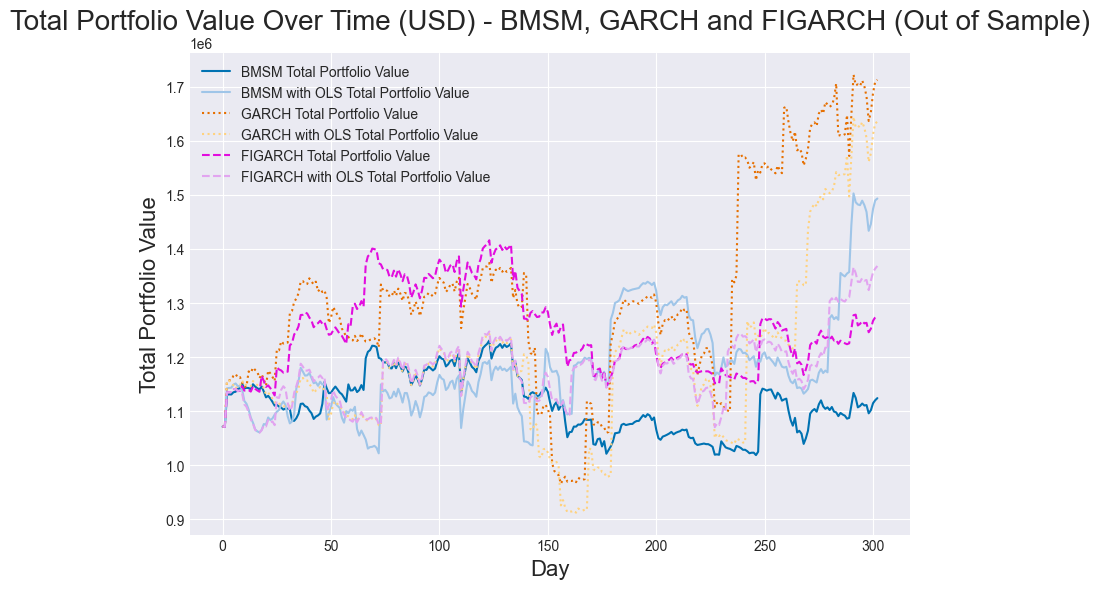

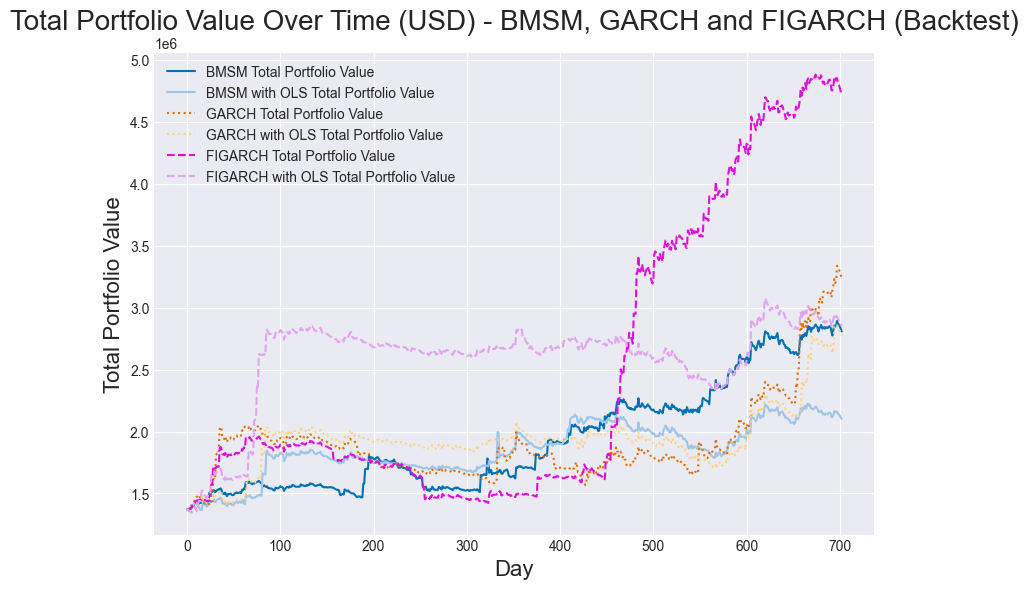

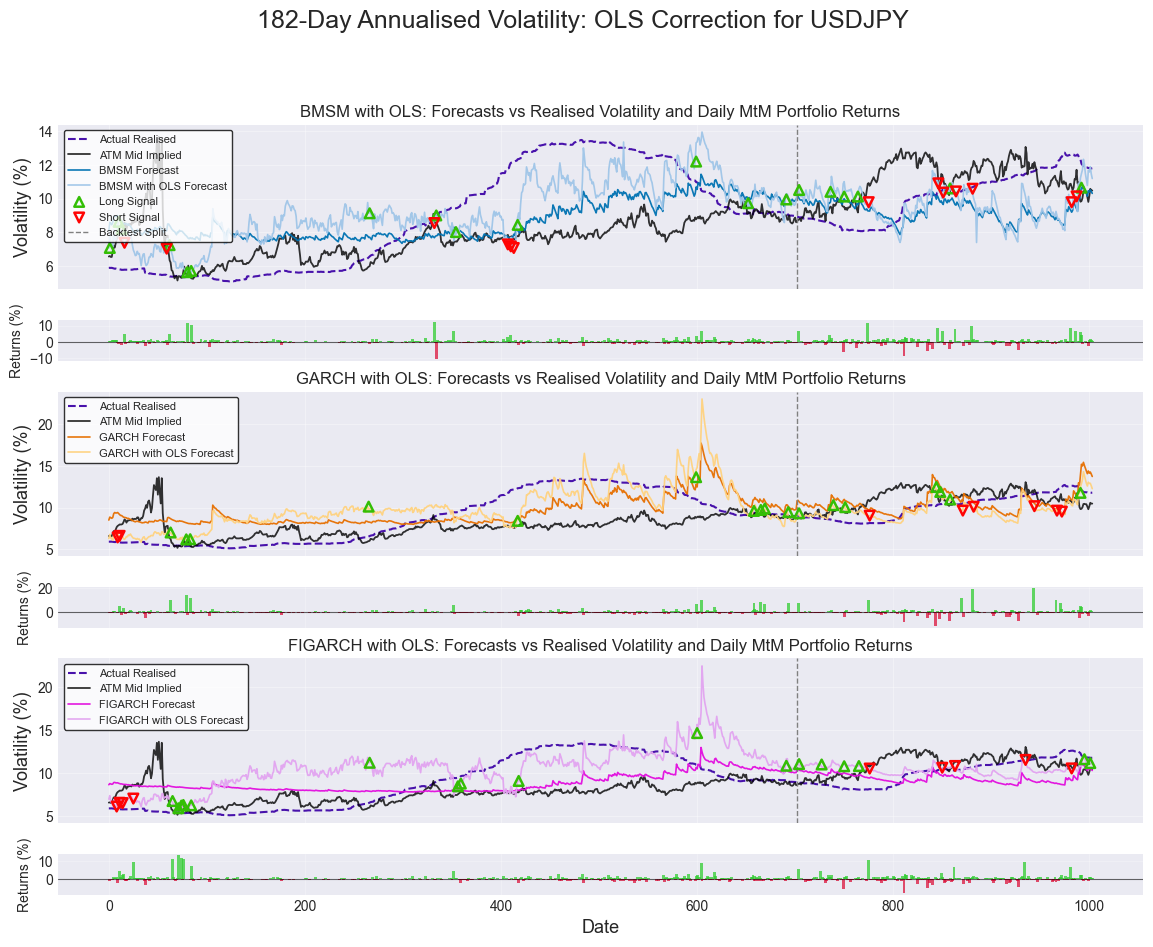

In [14]:
strategy_3 = Compare_Trading_Strategies(
    return_series=daily_log_returns_3, 
    realised_variance_series=realised_variance_3,
    atm_implied_vol_data=implied_vol_data_3,
    vol_smile_data=vol_smile_data_3,
    train_size=train_size,
    ticker=TICKER,
    initial_capital_domestic=IC_JPY,
    notional_base=NOTIONAL_USD,
    maximum_delta_difference=MAX_DELTA_DIFF,
    signal_lb=SIGNAL_LB,
    signal_ub=SIGNAL_UB,
    transaction_cost_indicator=TRANSACTION_COST_BOOL,
    transaction_costs_spot=TRANSACTION_COSTS_SPOT,
    transaction_costs_option=TRANSACTION_COSTS_OPTION,
    option_maturity=OPTION_MATURITY_3,
    forecast_horizon=H_3,
    spot_series=spot_curr_test_3,
    overnight_domestic_rate=overn_dom_r_test_3,
    overnight_foreign_rate=overn_for_r_test_3,
    domestic_rate=r_t_test_3,
    foreign_rate=r_b_test_3, 
    plots = False, 
    verbose=False, 
    sort_hyperparams_by=HYPERPARAM_SORT, 
    garch_1_2_indicator=GARCH_1_2_INDICATOR, 
    kbar=k_bar_MSM,
    b=b_MSM,
    gamma_kbar=gamma_kbar_MSM,
    convert_USD=CONVERT_USD_INDICATOR, 
    M = M, 
    long_thresholds=long_threshs,
    short_thresholds=short_threshs,
    sig_multipliers=sig_multipliers)

df_3 = strategy_3.compare_strategies(verbose = False)

In [15]:
df_3

,long_threshold,short_threshold,signal_multiplier,sharpe_ratio (USD),max_drawdown (USD),calmar_ratio (USD),cagr (USD),Precision (all),Precision (active),Win/loss ratio (all),Win/loss ratio (active),Avg win (all),Avg win (active),Avg loss (all),Avg loss (active),Non-active share,Total trades
BMSM Backtest,1.26,0.98,17.00,1.35,-16.20,1.59,29.28%,0.47,0.48,1.57,1.88,0.81%,1.03%,-0.52%,-0.55%,0.33,39.00
BMSM Out of Sample,1.26,0.98,17.00,0.20,-17.22,0.23,4.08%,0.51,0.53,0.99,0.96,0.73%,0.77%,-0.74%,-0.80%,0.22,6.00
BMSM with OLS Backtest,1.04,0.91,20.00,0.80,-16.35,0.94,16.52%,0.44,0.44,1.53,1.57,0.76%,0.78%,-0.50%,-0.50%,0.04,19.00
BMSM with OLS Out of Sample,1.04,0.91,20.00,0.90,-15.44,1.79,31.79%,0.52,0.52,1.13,1.16,1.14%,1.24%,-1.01%,-1.06%,0.10,13.00
GARCH Backtest,1.24,0.93,20.00,1.17,-23.51,1.31,36.08%,0.43,0.43,1.78,1.96,1.09%,1.30%,-0.61%,-0.66%,0.20,24.00
GARCH Out of Sample,1.24,0.93,20.00,0.95,-29.71,1.32,47.71%,0.51,0.54,1.25,1.13,1.37%,1.63%,-1.10%,-1.44%,0.29,21.00
GARCH with OLS Backtest,1.10,0.73,20.00,1.19,-17.90,1.41,28.72%,0.44,0.43,1.75,1.89,0.87%,0.94%,-0.50%,-0.50%,0.11,12.00
GARCH with OLS Out of Sample,1.10,0.73,20.00,0.89,-26.58,1.33,42.13%,0.48,0.58,1.41,1.04,1.32%,1.77%,-0.94%,-1.70%,0.48,13.00
FIGARCH Backtest,1.27,0.98,17.00,1.80,-27.37,1.62,55.71%,0.46,0.49,1.91,2.28,1.00%,1.31%,-0.52%,-0.58%,0.35,36.00
FIGARCH Out of Sample,1.27,0.98,17.00,0.70,-19.11,0.77,15.78%,0.53,0.54,1.04,1.01,0.80%,0.85%,-0.77%,-0.84%,0.21,10.00


# H=364, T=1Y

In [16]:
OPTION_MATURITY_4 = 1
H_4 = 364

vol_smile_data_4 = pd.read_csv("usdjpy_vol_smile_1y_extra.csv").set_index("CalculationDate")
implied_vol_data_4 = pd.DataFrame({
    'Exchange Date': vol_smile_data_4.index, 
    "Bid": vol_smile_data_4['ATM'], 
    "Ask": vol_smile_data_4['ATM'],
    "BidNet": vol_smile_data_4['ATM']})
Data_clean_4 = Clean_Implied_Vols_JPY_with_smile(data=implied_vol_data_4, 
                                start_date=start_date, 
                                end_date=end_date, 
                                align_df1=realised_variance_usdjpy, 
                                align_df2=daily_log_returns_usdjpy, 
                                smile_df=vol_smile_data_4)
implied_vol_data_4, realised_variance_4, daily_log_returns_4, vol_smile_data_4 = Data_clean_4.get_clean_data()

N_4 = len(daily_log_returns_4)
test_align_4 = daily_log_returns_4.iloc[N_4//2:-H_4]
spot_curr_test_4 = align_spots(spot_curr, test_align_4, start_date, end_date)

r_b_4 = pd.read_csv("SOFR_1y_compounded.csv").set_index("date")
r_t_4 = pd.read_csv("/Users/alexvillamartin/Documents/MSc Diss/Code/tona_1y_compounded.csv").set_index("Date")[['rate_pct']]

r_b_test_4, r_t_test_4, overn_dom_r_test_4, overn_for_r_test_4= sort_rates(r_b_4, r_t_4, overnight_domestic_rate, test_align_4, overnight_foreign_rate) 
r_b_test_4.ffill(inplace=True)

Estimated parameters: m0=1.324502e+00, sigma_bar=5.592794e-01
Final log-likelihood: -8.254789e+02
Estimated parameters: m0=1.310971e+00, sigma_bar=5.535291e-01
Final log-likelihood: -1.151542e+03


[I 2025-09-03 22:07:46,058] A new study created in memory with name: no-name-9a2c3b5a-c3d7-490d-a992-96038467401d
[I 2025-09-03 22:07:46,568] Trial 0 finished with value: 0.38418180296357657 and parameters: {'long_threshold': 1.1, 'short_threshold': 0.83, 'signal_multiplier': 20}. Best is trial 0 with value: 0.38418180296357657.
[I 2025-09-03 22:07:47,081] Trial 1 finished with value: 0.88745364159566 and parameters: {'long_threshold': 1.15, 'short_threshold': 0.96, 'signal_multiplier': 17}. Best is trial 1 with value: 0.88745364159566.
[I 2025-09-03 22:07:47,520] Trial 2 finished with value: -0.19087946738680106 and parameters: {'long_threshold': 1.18, 'short_threshold': 0.91, 'signal_multiplier': 7}. Best is trial 1 with value: 0.88745364159566.
[I 2025-09-03 22:07:47,988] Trial 3 finished with value: 0.4049928078032464 and parameters: {'long_threshold': 1.14, 'short_threshold': 0.76, 'signal_multiplier': 20}. Best is trial 1 with value: 0.88745364159566.
[I 2025-09-03 22:07:48,566] 

Estimated parameters: omega=0.0037585331153215874, alpha=0.0672, beta=0.9232
Estimated parameters: omega=0.0024468845943431145, alpha=0.0578, beta=0.9363


[I 2025-09-03 22:14:52,833] A new study created in memory with name: no-name-c774033c-23b8-4c42-9a71-13fef60207dd
[I 2025-09-03 22:14:53,508] Trial 0 finished with value: 0.031031729321790085 and parameters: {'long_threshold': 1.1, 'short_threshold': 0.83, 'signal_multiplier': 20}. Best is trial 0 with value: 0.031031729321790085.
[I 2025-09-03 22:14:54,163] Trial 1 finished with value: -0.3018275260917545 and parameters: {'long_threshold': 1.15, 'short_threshold': 0.96, 'signal_multiplier': 17}. Best is trial 0 with value: 0.031031729321790085.
[I 2025-09-03 22:14:54,801] Trial 2 finished with value: -0.07844306537487611 and parameters: {'long_threshold': 1.18, 'short_threshold': 0.91, 'signal_multiplier': 7}. Best is trial 0 with value: 0.031031729321790085.
[I 2025-09-03 22:14:55,461] Trial 3 finished with value: 0.567971583632112 and parameters: {'long_threshold': 1.14, 'short_threshold': 0.76, 'signal_multiplier': 20}. Best is trial 3 with value: 0.567971583632112.
[I 2025-09-03 2

Estimated parameters: omega=0.07868108445557308, d=0.2129, beta=0.0485
Final log-likelihood = 398.4028
Estimated parameters: omega=0.060293733896601295, d=0.2454, beta=0.1119
Final log-likelihood = 745.3353


[I 2025-09-03 22:23:49,991] A new study created in memory with name: no-name-643be2cf-13fe-4611-a7d6-0c3a7e8fe2a2
[I 2025-09-03 22:23:50,481] Trial 0 finished with value: 0.8677940175634493 and parameters: {'long_threshold': 1.1, 'short_threshold': 0.83, 'signal_multiplier': 20}. Best is trial 0 with value: 0.8677940175634493.
[I 2025-09-03 22:23:50,936] Trial 1 finished with value: 1.2967380835114715 and parameters: {'long_threshold': 1.15, 'short_threshold': 0.96, 'signal_multiplier': 17}. Best is trial 1 with value: 1.2967380835114715.
[I 2025-09-03 22:23:51,350] Trial 2 finished with value: 0.26978465783487143 and parameters: {'long_threshold': 1.18, 'short_threshold': 0.91, 'signal_multiplier': 7}. Best is trial 1 with value: 1.2967380835114715.
[I 2025-09-03 22:23:51,785] Trial 3 finished with value: 1.0223841509939775 and parameters: {'long_threshold': 1.14, 'short_threshold': 0.76, 'signal_multiplier': 20}. Best is trial 1 with value: 1.2967380835114715.
[I 2025-09-03 22:23:52,

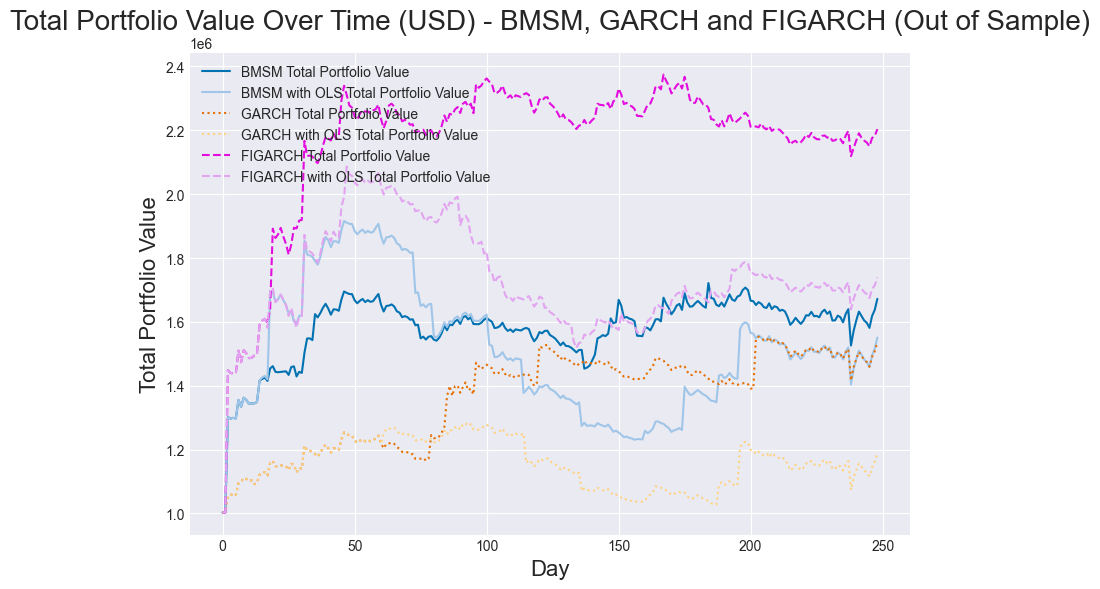

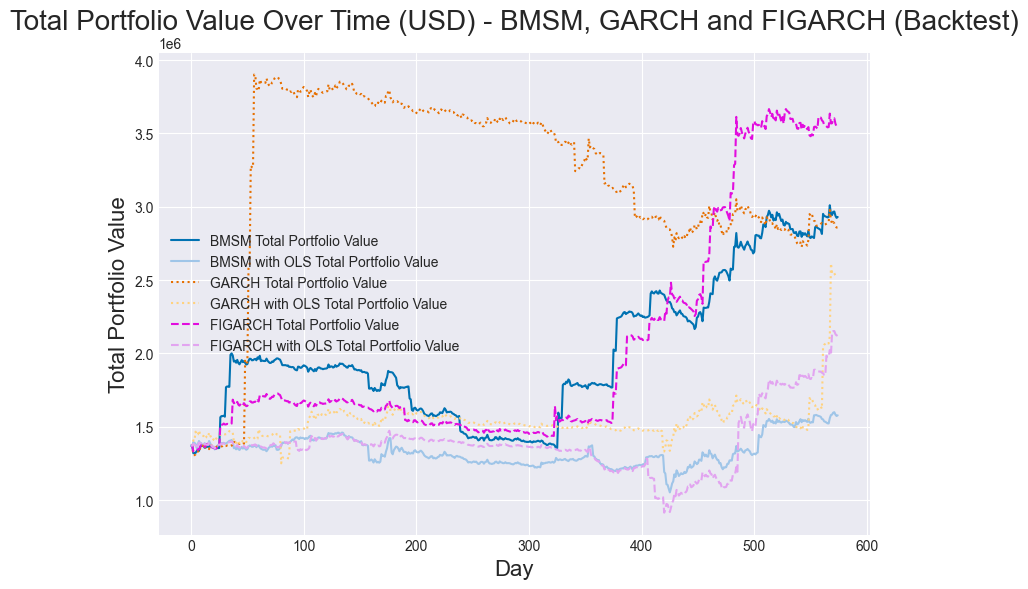

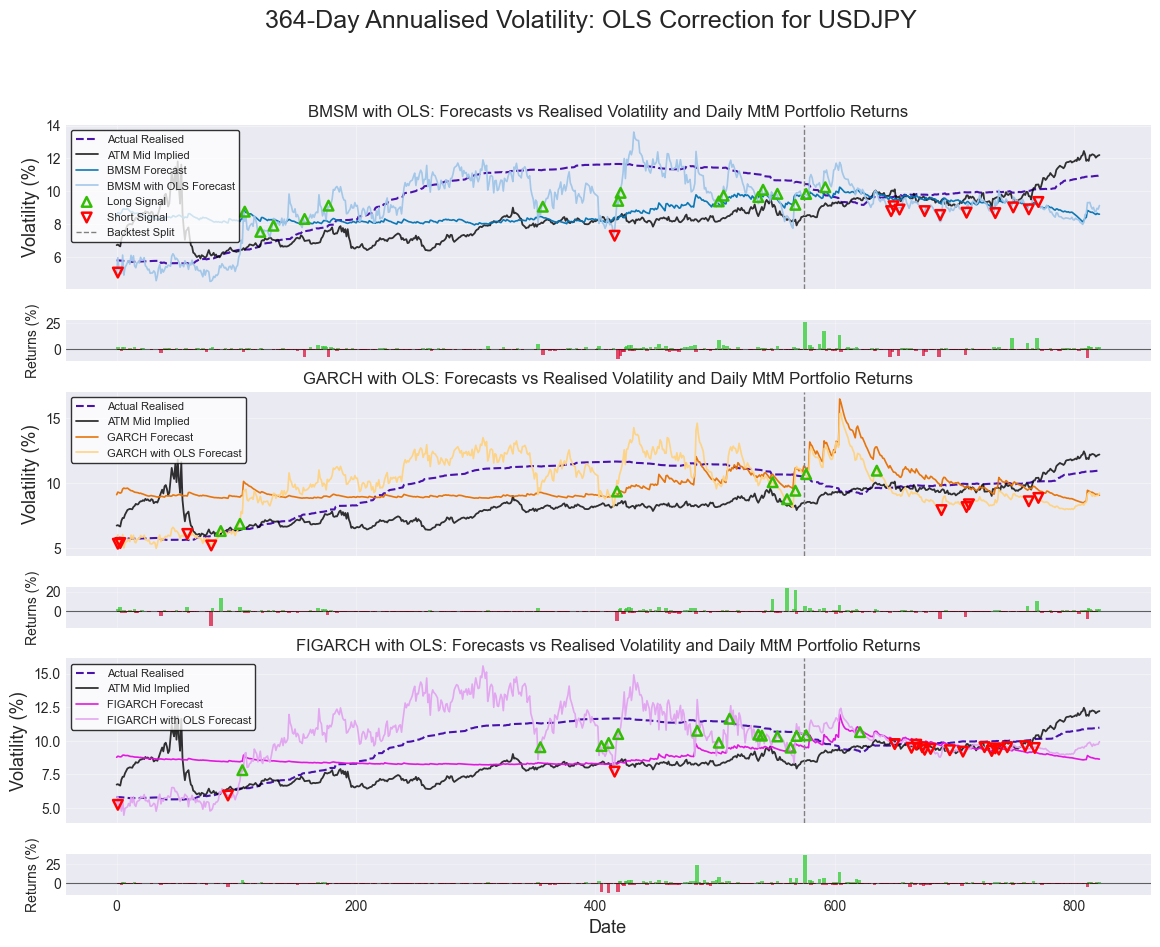

In [17]:
strategy_4 = Compare_Trading_Strategies(
    return_series=daily_log_returns_4, 
    realised_variance_series=realised_variance_4,
    atm_implied_vol_data=implied_vol_data_4,
    vol_smile_data=vol_smile_data_4,
    train_size=train_size,
    ticker=TICKER,
    initial_capital_domestic=IC_JPY,
    notional_base=NOTIONAL_USD,
    maximum_delta_difference=MAX_DELTA_DIFF,
    signal_lb=SIGNAL_LB,
    signal_ub=SIGNAL_UB,
    transaction_cost_indicator=TRANSACTION_COST_BOOL,
    transaction_costs_spot=TRANSACTION_COSTS_SPOT,
    transaction_costs_option=TRANSACTION_COSTS_OPTION,
    option_maturity=OPTION_MATURITY_4,
    forecast_horizon=H_4,
    spot_series=spot_curr_test_4,
    overnight_domestic_rate=overn_dom_r_test_4,
    overnight_foreign_rate=overn_for_r_test_4,
    domestic_rate=r_t_test_4,
    foreign_rate=r_b_test_4, 
    plots = False, 
    verbose=False, 
    sort_hyperparams_by=HYPERPARAM_SORT, 
    garch_1_2_indicator=GARCH_1_2_INDICATOR, 
    kbar=k_bar_MSM,
    b=b_MSM,
    gamma_kbar=gamma_kbar_MSM,
    convert_USD=CONVERT_USD_INDICATOR, 
    M = M, 
    long_thresholds=long_threshs,
    short_thresholds=short_threshs,
    sig_multipliers=sig_multipliers)

df_4 = strategy_4.compare_strategies(verbose = False)

In [18]:
df_4

,long_threshold,short_threshold,signal_multiplier,sharpe_ratio (USD),max_drawdown (USD),calmar_ratio (USD),cagr (USD),Precision (all),Precision (active),Win/loss ratio (all),Win/loss ratio (active),Avg win (all),Avg win (active),Avg loss (all),Avg loss (active),Non-active share,Total trades
BMSM Backtest,1.21,0.95,20.00,1.19,-32.41,1.03,39.48%,0.46,0.48,1.70,1.99,0.94%,1.29%,-0.55%,-0.65%,0.39,32.00
BMSM Out of Sample,1.21,0.95,20.00,1.54,-14.26,3.64,67.79%,0.50,0.54,1.53,1.69,1.19%,1.81%,-0.78%,-1.07%,0.55,11.00
BMSM with OLS Backtest,1.24,0.85,20.00,0.31,-27.94,0.22,6.35%,0.48,0.48,1.18,1.16,0.80%,0.83%,-0.68%,-0.71%,0.11,16.00
BMSM with OLS Out of Sample,1.24,0.85,20.00,1.00,-35.76,1.24,55.49%,0.45,0.49,1.64,1.68,1.50%,2.53%,-0.92%,-1.50%,0.56,12.00
GARCH Backtest,1.26,0.76,20.00,0.85,-30.13,1.07,37.97%,0.42,0.42,2.02,2.26,0.92%,1.12%,-0.46%,-0.49%,0.23,11.00
GARCH Out of Sample,1.26,0.76,20.00,1.75,-8.95,4.84,53.97%,0.46,0.50,1.73,2.00,1.12%,1.60%,-0.65%,-0.80%,0.46,6.00
GARCH with OLS Backtest,1.09,0.75,20.00,0.88,-19.85,1.35,30.66%,0.45,0.45,1.59,1.60,0.96%,1.01%,-0.60%,-0.63%,0.08,10.00
GARCH with OLS Out of Sample,1.09,0.75,20.00,0.73,-19.87,0.87,18.74%,0.47,0.50,1.32,1.39,0.97%,1.39%,-0.74%,-1.00%,0.50,7.00
FIGARCH Backtest,1.15,0.98,20.00,1.63,-17.03,2.46,51.83%,0.46,0.47,1.90,2.29,0.94%,1.21%,-0.49%,-0.53%,0.32,28.00
FIGARCH Out of Sample,1.15,0.98,20.00,1.79,-10.77,7.43,121.85%,0.50,0.51,2.00,2.45,1.30%,1.71%,-0.65%,-0.70%,0.37,11.00
